In [30]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

#Data loading

#Train data
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    zoom_range=0.3,
    width_shift_range=0.3,
    height_shift_range=0.3,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(rescale=1./255)

In [31]:
#load train set
train_data = train_gen.flow_from_directory(
    "lemon_leaf_dataset/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 6913 images belonging to 9 classes.


In [32]:
#load test data
test_data = test_gen.flow_from_directory(
    "lemon_leaf_dataset/test",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 1731 images belonging to 9 classes.


In [33]:
#Buid model using MobileNetV2
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)

output = Dense(9, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


In [34]:
#Fine tuning
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

In [35]:
#Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
#Train model
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=20
)

Epoch 1/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 68s 299ms/step - accuracy: 0.8079 - loss: 0.5716 - val_accuracy: 0.7221 - val_loss: 1.0578
Epoch 2/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 69s 317ms/step - accuracy: 0.9238 - loss: 0.2251 - val_accuracy: 0.7666 - val_loss: 0.6997
Epoch 3/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 82s 378ms/step - accuracy: 0.9471 - loss: 0.1632 - val_accuracy: 0.8070 - val_loss: 0.6164
Epoch 4/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 95s 439ms/step - accuracy: 0.9552 - loss: 0.1301 - val_accuracy: 0.8550 - val_loss: 0.4453
Epoch 5/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 90s 415ms/step - accuracy: 0.9670 - loss: 0.1018 - val_accuracy: 0.8446 - val_loss: 0.5484
Epoch 6/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 93s 428ms/step - accuracy: 0.9690 - loss: 0.0975 - val_accuracy: 0.8642 - val_loss: 0.4597
Epoch 7/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 98s 450ms/step - accuracy: 0.9682 - loss: 0.0909 - val_accuracy: 0.8885 - val_loss: 0.3753
Epoch 8/20
217/217 ━━━━━━━━━━━━━━━━━━━━ 107s 494ms/step - accuracy: 0.9711 - loss: 

In [37]:
#Evaluation model
loss, acc = model.evaluate(test_data)

print("Test Accuracy:", acc)
print("Test Loss:", loss)

55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 187ms/step - accuracy: 0.9804 - loss: 0.0671
Test Accuracy: 0.9803581833839417
Test Loss: 0.0670548528432846


In [38]:
#Save model
model.save("lemon_disease_model.keras")

In [39]:
#load model 
from tensorflow.keras.models import load_model

model = load_model("lemon_disease_model.keras")

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


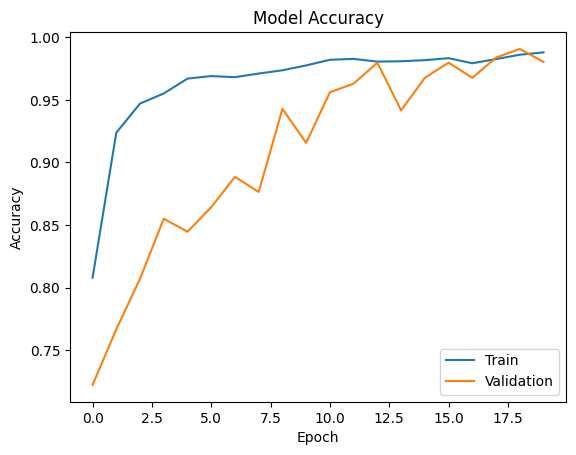

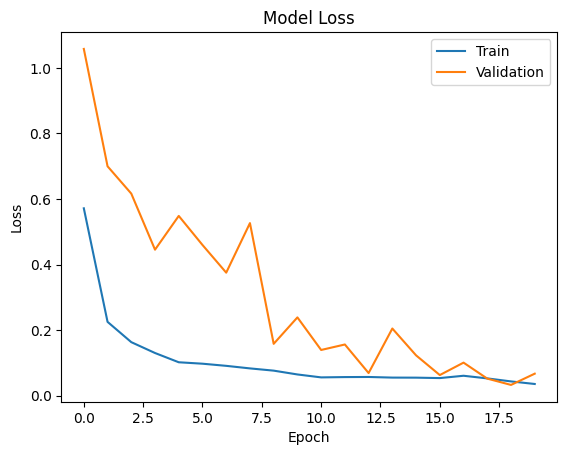

In [40]:
#Performance graphs
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])
plt.show()

In [41]:
#Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = model.predict(test_data)
y_pred = np.argmax(y_pred, axis=1)

print(confusion_matrix(test_data.classes, y_pred))
print(classification_report(test_data.classes, y_pred))

55/55 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step
[[25 25 21 21 24 26 14 19 17]
 [22 10 26 25 24 19 21 22 28]
 [20 17 18 12 21 29 21 22 24]
 [24 24 13 16 20 27 25 19 14]
 [15 24 21 20 22 15 26 18 24]
 [20 31 22 20 28 20 18 19 20]
 [25 24 15 15 20 24 18 26 26]
 [14 21 26 19 27 17 25 26 25]
 [27 21 20  8 26 21 26 29 22]]
              precision    recall  f1-score   support

           0       0.13      0.13      0.13       192
           1       0.05      0.05      0.05       197
           2       0.10      0.10      0.10       184
           3       0.10      0.09      0.09       182
           4       0.10      0.12      0.11       185
           5       0.10      0.10      0.10       198
           6       0.09      0.09      0.09       193
           7       0.13      0.13      0.13       200
           8       0.11      0.11      0.11       200

    accuracy                           0.10      1731
   macro avg       0.10      0.10      0.10      1731
weighted avg       0.10      0.10     

In [42]:
print(train_data.class_indices)

{'Anthracnose': 0, 'Bacterial Blight': 1, 'Citrus Canker': 2, 'Curl Virus': 3, 'Deficiency Leaf': 4, 'Dry Leaf': 5, 'Healthy Leaf': 6, 'Sooty Mould': 7, 'Spider Mites': 8}


In [43]:
class_names = list(train_data.class_indices.keys())

print(class_names)

['Anthracnose', 'Bacterial Blight', 'Citrus Canker', 'Curl Virus', 'Deficiency Leaf', 'Dry Leaf', 'Healthy Leaf', 'Sooty Mould', 'Spider Mites']


In [70]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_disease(img_path):

    # load image
    img = image.load_img(img_path, target_size=(224,224))

    # convert to array
    img_array = image.img_to_array(img)

    # normalize
    img_array = img_array / 255.0

    # add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # predict
    prediction = model.predict(img_array)[0]

    # highest probability index
    class_index = np.argmax(prediction)

    # disease name from index
    disease_name = class_names[class_index]

    # confidence score
    confidence = np.max(prediction)

    print("Disease:", disease_name)
    print("Confidence:", confidence)

    return disease_name, confidence

In [45]:

#class label
class_names = [
    "Anthracnose",
    "Bacterial Blight",
    "Citrus Canker",
    "Curl Virus",
    "Deficiency Leaf",
    "Dry Leaf",
    "Healthy Leaf",
    "Sooty Mould",
    "Spider Mites"
]



In [46]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/IEEE_lemonleaf/Original_Dataset/Anthracnose/Anthracnose00001.JPG")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
Disease: Anthracnose
Confidence: 1.0


('Anthracnose', np.float32(1.0))

In [47]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/IEEE_lemonleaf/Original_Dataset/Anthracnose/Anthracnose00050.JPG")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Disease: Anthracnose
Confidence: 0.9999622


('Anthracnose', np.float32(0.9999622))

In [48]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/IEEE_lemonleaf/Original_Dataset/Bacterial Blight/bacterial_blight00001.JPG")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Disease: Bacterial Blight
Confidence: 0.9997863


('Bacterial Blight', np.float32(0.9997863))

In [49]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/IEEE_lemonleaf/Original_Dataset/Bacterial Blight/bacterial_blight00071.JPG")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Disease: Bacterial Blight
Confidence: 0.9999994


('Bacterial Blight', np.float32(0.9999994))

In [50]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/IEEE_lemonleaf/Original_Dataset/Citrus Canker/Citrus_Canker00016.JPG")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Disease: Citrus Canker
Confidence: 1.0


('Citrus Canker', np.float32(1.0))

In [51]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/IEEE_lemonleaf/Original_Dataset/Citrus Canker/Citrus_Canker00121.JPG")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Disease: Citrus Canker
Confidence: 1.0


('Citrus Canker', np.float32(1.0))

In [52]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/IEEE_lemonleaf/Original_Dataset/Curl Virus/curl_virus00006.JPG")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Disease: Curl Virus
Confidence: 0.9999989


('Curl Virus', np.float32(0.9999989))

In [53]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/IEEE_lemonleaf/Original_Dataset/Curl Virus/curl_virus00098.JPG")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Disease: Curl Virus
Confidence: 0.9999616


('Curl Virus', np.float32(0.9999616))

In [54]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/IEEE_lemonleaf/Original_Dataset/Deficiency Leaf/Deficiency_leaf00045.JPG")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Disease: Deficiency Leaf
Confidence: 0.999998


('Deficiency Leaf', np.float32(0.999998))

In [55]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/IEEE_lemonleaf/Original_Dataset/Deficiency Leaf/Deficiency_leaf00086.JPG")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Disease: Deficiency Leaf
Confidence: 0.99999917


('Deficiency Leaf', np.float32(0.99999917))

In [56]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/IEEE_lemonleaf/Original_Dataset/Dry Leaf/Dry_leaf00091.JPG")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Disease: Dry Leaf
Confidence: 1.0


('Dry Leaf', np.float32(1.0))

In [57]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/IEEE_lemonleaf/Original_Dataset/Dry Leaf/Dry_leaf00027.JPG")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Disease: Dry Leaf
Confidence: 0.9995334


('Dry Leaf', np.float32(0.9995334))

In [58]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/IEEE_lemonleaf/Original_Dataset/Healthy Leaf/Healthy_leaf00008.JPG")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Disease: Healthy Leaf
Confidence: 0.9945857


('Healthy Leaf', np.float32(0.9945857))

In [59]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/IEEE_lemonleaf/Original_Dataset/Healthy Leaf/Healthy_leaf00035.JPG")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Disease: Healthy Leaf
Confidence: 0.9999542


('Healthy Leaf', np.float32(0.9999542))

In [60]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/IEEE_lemonleaf/Original_Dataset/Sooty Mould/sooty_mould00113.JPG")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Disease: Sooty Mould
Confidence: 0.99999785


('Sooty Mould', np.float32(0.99999785))

In [61]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/IEEE_lemonleaf/Original_Dataset/Sooty Mould/sooty_mould00011.JPG")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Disease: Sooty Mould
Confidence: 0.9999999


('Sooty Mould', np.float32(0.9999999))

In [62]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/IEEE_lemonleaf/Original_Dataset/Spider Mites/spider_mites00009.JPG")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Disease: Spider Mites
Confidence: 0.99988925


('Spider Mites', np.float32(0.99988925))

In [63]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/IEEE_lemonleaf/Original_Dataset/Spider Mites/spider_mites00082.JPG")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Disease: Spider Mites
Confidence: 0.9997129


('Spider Mites', np.float32(0.9997129))

In [64]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Anthracnose/aug_Anthracnose_722.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Anthracnose/aug_Anthracnose_732.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Anthracnose/aug_Anthracnose_742.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Anthracnose/aug_Anthracnose_752.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Anthracnose/aug_Anthracnose_762.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Disease: Anthracnose
Confidence: 0.99942696
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Disease: Anthracnose
Confidence: 0.99986374
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Disease: Anthracnose
Confidence: 0.9999666
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Disease: Anthracnose
Confidence: 0.99999654
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Disease: Anthracnose
Confidence: 0.9956222


('Anthracnose', np.float32(0.9956222))

In [65]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Bacterial Blight/aug_Bacterial Blight_100.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Bacterial Blight/aug_Bacterial Blight_105.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Bacterial Blight/aug_Bacterial Blight_125.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Bacterial Blight/aug_Bacterial Blight_150.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Bacterial Blight/aug_Bacterial Blight_160.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Disease: Bacterial Blight
Confidence: 0.9999982
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Disease: Bacterial Blight
Confidence: 0.99999785
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Disease: Bacterial Blight
Confidence: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Disease: Bacterial Blight
Confidence: 0.99999666
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Disease: Bacterial Blight
Confidence: 1.0


('Bacterial Blight', np.float32(1.0))

In [66]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Citrus Canker/aug_Citrus Canker_723.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Citrus Canker/aug_Citrus Canker_733.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Citrus Canker/aug_Citrus Canker_743.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Citrus Canker/aug_Citrus Canker_753.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Citrus Canker/aug_Citrus Canker_763.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Disease: Citrus Canker
Confidence: 0.9897586
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Disease: Citrus Canker
Confidence: 0.993397
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Disease: Citrus Canker
Confidence: 0.99425876
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Disease: Citrus Canker
Confidence: 0.9999825
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Disease: Citrus Canker
Confidence: 0.9957755


('Citrus Canker', np.float32(0.9957755))

In [72]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Curl Virus/aug_Curl Virus_740.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Curl Virus/aug_Curl Virus_744.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Curl Virus/aug_Curl Virus_754.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Curl Virus/aug_Curl Virus_764.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Curl Virus/aug_Curl Virus_774.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Disease: Curl Virus
Confidence: 0.999268
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Disease: Curl Virus
Confidence: 0.94000876
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Disease: Curl Virus
Confidence: 0.9985287
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Disease: Curl Virus
Confidence: 0.9905822
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Disease: Curl Virus
Confidence: 0.99607134


('Curl Virus', np.float32(0.99607134))

In [73]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Deficiency Leaf/aug_Deficiency Leaf_730.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Deficiency Leaf/aug_Deficiency Leaf_740.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Deficiency Leaf/aug_Deficiency Leaf_750.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Deficiency Leaf/aug_Deficiency Leaf_760.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Deficiency Leaf/aug_Deficiency Leaf_770.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Disease: Deficiency Leaf
Confidence: 0.99981195
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Disease: Deficiency Leaf
Confidence: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Disease: Deficiency Leaf
Confidence: 0.9999894
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Disease: Deficiency Leaf
Confidence: 0.99746525
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Disease: Deficiency Leaf
Confidence: 0.9999974


('Deficiency Leaf', np.float32(0.9999974))

In [74]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Dry Leaf/aug_Dry Leaf_100.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Dry Leaf/aug_Dry Leaf_110.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Dry Leaf/aug_Dry Leaf_120.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Dry Leaf/aug_Dry Leaf_130.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Dry Leaf/aug_Dry Leaf_140.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Disease: Dry Leaf
Confidence: 0.99999607
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Disease: Dry Leaf
Confidence: 0.99999917
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Disease: Dry Leaf
Confidence: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Disease: Dry Leaf
Confidence: 0.999895
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Disease: Dry Leaf
Confidence: 0.99999094


('Dry Leaf', np.float32(0.99999094))

In [75]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Healthy Leaf/aug_Healthy Leaf_730.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Healthy Leaf/aug_Healthy Leaf_740.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Healthy Leaf/aug_Healthy Leaf_750.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Healthy Leaf/aug_Healthy Leaf_760.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Healthy Leaf/aug_Healthy Leaf_770.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Disease: Healthy Leaf
Confidence: 0.9999907
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Disease: Healthy Leaf
Confidence: 0.9999801
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Disease: Healthy Leaf
Confidence: 0.99989676
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Disease: Healthy Leaf
Confidence: 0.99998283
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Disease: Healthy Leaf
Confidence: 0.9999417


('Healthy Leaf', np.float32(0.9999417))

In [76]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Sooty Mould/aug_Sooty Mould_100.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Sooty Mould/aug_Sooty Mould_110.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Sooty Mould/aug_Sooty Mould_120.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Sooty Mould/aug_Sooty Mould_130.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Sooty Mould/aug_Sooty Mould_140.jpg")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Disease: Sooty Mould
Confidence: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Disease: Sooty Mould
Confidence: 0.9999994
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Disease: Sooty Mould
Confidence: 0.9998807
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Disease: Sooty Mould
Confidence: 0.99999917
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Disease: Sooty Mould
Confidence: 1.0


('Sooty Mould', np.float32(1.0))

In [77]:
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Spider Mites/aug_Spider Mites_100.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Spider Mites/aug_Spider Mites_110.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Spider Mites/aug_Spider Mites_120.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Spider Mites/aug_Spider Mites_130.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Spider Mites/aug_Spider Mites_140.jpg")
predict_disease("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Spider Mites/aug_Spider Mites_150.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Disease: Spider Mites
Confidence: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Disease: Spider Mites
Confidence: 0.99999976
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Disease: Spider Mites
Confidence: 0.99977285
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Disease: Spider Mites
Confidence: 0.99999964
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Disease: Spider Mites
Confidence: 1.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Disease: Spider Mites
Confidence: 1.0


('Spider Mites', np.float32(1.0))